Features shape: (20640, 8)
Target shape: (20640,)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Root Mean Squared Error: 0.7455813830127762
R^2 Score: 0.575787706032451

Top features by absolute weight:
Latitude      0.896929
Longitude     0.869842
MedInc        0.854383
AveBedrms     0.339259
AveRooms      0.294410
HouseAge      0.122546
AveOccup      0.040829
Population    0.002308
dtype: float64


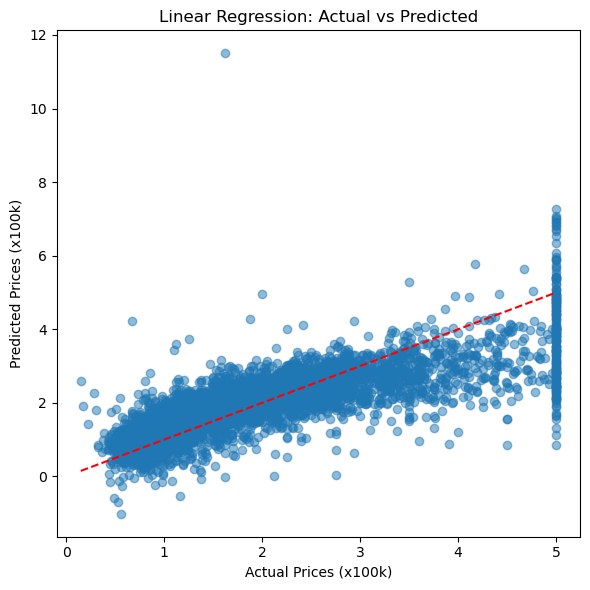

In [1]:
#!/usr/bin/env python3
"""
Standard Linear Regression on California Housing dataset
(no animation, just training and evaluation).
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load dataset
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target  # median house value in 100,000s

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Feature names:", list(X.columns))

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Preprocess (standardize features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 4. Linear regression model
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)

# 5. Predictions
y_pred = reg.predict(X_test_scaled)

# 6. Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Root Mean Squared Error:", rmse)
print("R^2 Score:", r2)

# 7. Coefficients
coef = pd.Series(reg.coef_, index=X.columns)
print("\nTop features by absolute weight:")
print(coef.abs().sort_values(ascending=False).head(10))

# 8. Optional: Plot predicted vs actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Prices (x100k)")
plt.ylabel("Predicted Prices (x100k)")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()